<a href="https://colab.research.google.com/github/ishrat-waheed/learn_python/blob/main/EDA_ML_LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")
# Display first 5 rows
print(df.head())
# Summary statistics
print("Mean Age:", df["age"].mean())
print("Median Age:", df["age"].median())
print("Mode of Class:", df["class"].mode()[0])
print("Standard Deviation of Fare:", df["fare"].std())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Mean Age: 29.69911764705882
Median Age: 28.0
Mode of Class: Third
Standard Deviation of Fare: 49.693428597180905


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')


In [3]:
# View first 5 rows
print(titanic.head())
# Check dataset shape (rows, columns)
print("Shape:", titanic.shape)
# Summary of numerical features
print(titanic.describe())
# Check data types and missing values
print(titanic.info())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Shape: (891, 15)
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0

In [4]:
# Check missing values
print(titanic.isnull().sum())
# Drop rows with missing 'embarked' values
titanic.dropna(subset=['embarked'], inplace=True)
# Impute missing 'age' values with the median
titanic['age'].fillna(titanic['age'].median(), inplace=True)


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/tmp/ipykernel_13582/3648159422.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)


In [5]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
df['age'] = df['age'].fillna(df['age'].median())

In [12]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["fare"] >= Q1 - 1.5*IQR) & (df["fare"] <= Q3 + 1.5*IQR)]


Mean Age: 29.315151856017994
Median Age: 28.0


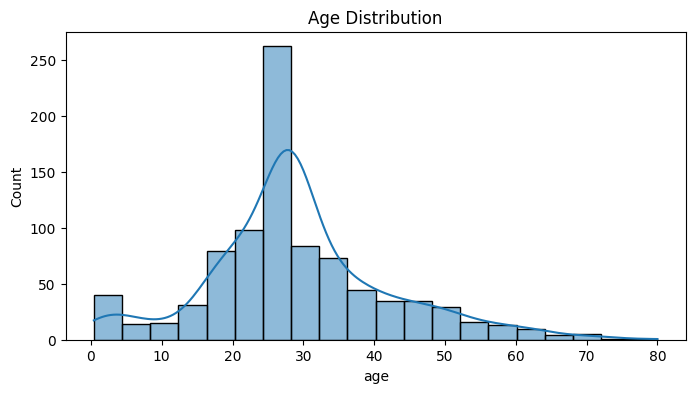

In [13]:
# Mean and median of 'age'
print("Mean Age:", titanic['age'].mean())
print("Median Age:", titanic['age'].median())
# Histogram of 'age'
plt.figure(figsize=(8, 4))
sns.histplot(titanic['age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.show()



sex
female    0.740385
male      0.188908
Name: survived, dtype: float64
Correlation Matrix:
                age      fare  survived
age       1.000000  0.093707 -0.069822
fare      0.093707  1.000000  0.255290
survived -0.069822  0.255290  1.000000


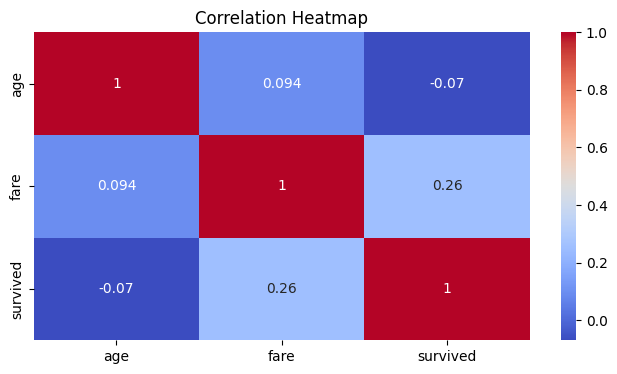

In [14]:
# Survival rate by gender
print(titanic.groupby('sex')['survived'].mean())


# Correlation matrix (numerical features)
corr_matrix = titanic[['age', 'fare', 'survived']].corr()
print("Correlation Matrix:\n", corr_matrix)
# Heatmap of correlations
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


            survived    pclass       age     sibsp     parch      fare  \
survived    1.000000 -0.219870 -0.124165 -0.003237  0.096196  0.180374   
pclass     -0.219870  1.000000 -0.343962  0.127484  0.100833 -0.593969   
age        -0.124165 -0.343962  1.000000 -0.346854 -0.214153  0.046588   
sibsp      -0.003237  0.127484 -0.346854  1.000000  0.417657  0.447603   
parch       0.096196  0.100833 -0.214153  0.417657  1.000000  0.385990   
fare        0.180374 -0.593969  0.046588  0.447603  0.385990  1.000000   
adult_male -0.520361 -0.048121  0.311554 -0.357339 -0.399234 -0.233766   
alone      -0.186483 -0.041392  0.288016 -0.671838 -0.595196 -0.481859   

            adult_male     alone  
survived     -0.520361 -0.186483  
pclass       -0.048121 -0.041392  
age           0.311554  0.288016  
sibsp        -0.357339 -0.671838  
parch        -0.399234 -0.595196  
fare         -0.233766 -0.481859  
adult_male    1.000000  0.456195  
alone         0.456195  1.000000  


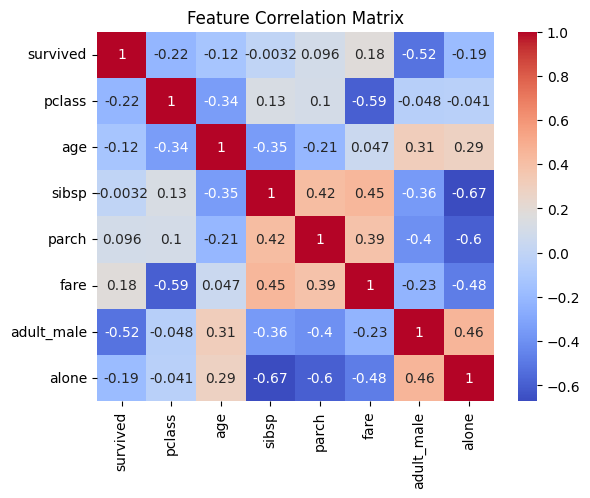

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
# Compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)
# Visualizing correlation using heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

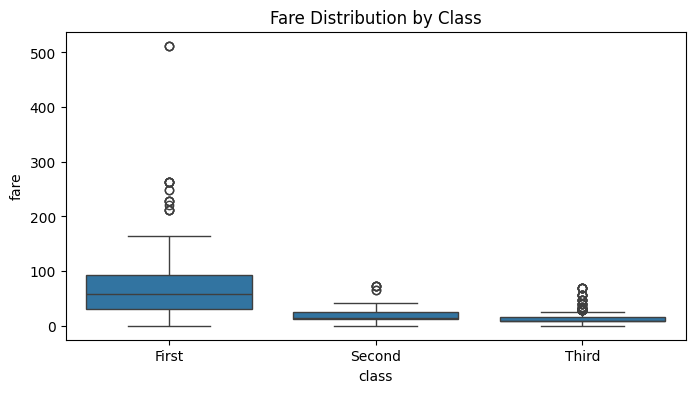

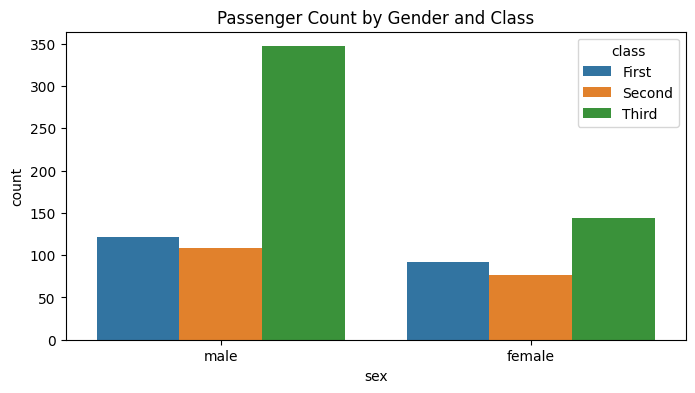

In [18]:
# Box plot of 'fare' by 'class'
plt.figure(figsize=(8, 4))
sns.boxplot(x='class', y='fare', data=titanic)
plt.title('Fare Distribution by Class')
plt.show()

# Survival count by 'sex' and 'class'
plt.figure(figsize=(8, 4))
sns.countplot(x='sex', hue='class', data=titanic)
plt.title('Passenger Count by Gender and Class')
plt.show()
